In [1]:
from spacerocks import SpaceRock, Units
import numpy as np

In [2]:
import pandas as pd

In [3]:
df = pd.read_json('https://minorplanetcenter.net/Extended_Files/mpcorb_extended.json.gz')

In [41]:
df = df[df.H < 4.4]

In [42]:
units = Units()
units.current()

Quantity             Unit           
---------------------------------------
distance             AU             
angle                deg            
timescale            utc            
timeformat           None           
speed                AU / d         
rotation_period      d              


In [43]:
df.Principal_desig

0            A801 AA
1            A802 FA
3            A807 FA
19999     2000 WR106
28977      2001 KX76
42300     2001 UR163
49999      2002 LM60
55564     2002 AW197
55635     2002 TX300
55636      2002 UX25
84521     2002 TC302
84921       2003 VS2
90376      2003 VB12
90481        2004 DW
90567       2004 GV9
120177     2003 OP32
120346     2004 SB60
134339       1930 BM
136107     2003 EL61
136198    2003 UB313
136471      2005 FY9
145451     2005 RN43
145452     2005 RR43
174566     2003 MW12
202420    2005 UQ513
208995     2003 AZ84
225087     2007 OR10
229761    2007 UK126
230964    2004 XA192
303774    2005 QU182
307260      2002 MS4
471142    2010 EK139
523670     2013 FZ27
523691     2014 EZ51
523793    2015 RR245
532036     2013 FY27
585974    2004 XR190
610809    2006 QH181
688164    2010 JO179
688530     2010 KZ39
692263     2010 RF43
744240    2012 VP113
815635    2014 UZ224
854892    2015 KH162
948664    2017 FO161
971640     2018 AG37
980763     2018 VG18
Name: Princip

In [44]:
df.Name

0                   Ceres
1                  Pallas
3                   Vesta
19999              Varuna
28977               Ixion
42300                 NaN
49999              Quaoar
55564                 NaN
55635                 NaN
55636                 NaN
84521                 NaN
84921                 NaN
90376               Sedna
90481               Orcus
90567                 NaN
120177                NaN
120346            Salacia
134339              Pluto
136107             Haumea
136198               Eris
136471           Makemake
145451                NaN
145452                NaN
174566              Varda
202420                NaN
208995                NaN
225087           Gonggong
229761    G!kun||'homdima
230964                NaN
303774                NaN
307260                NaN
471142          Dziewanna
523670                NaN
523691                NaN
523793                NaN
532036                NaN
585974                NaN
610809                NaN
688164      

In [45]:
np.unique(df.Epoch)

array([2459000.5, 2459200.5])

In [46]:
rocks = SpaceRock(a=df.a, 
                  e=df.e, 
                  inc=df.i, 
                  arg=df.Peri, 
                  node=df.Node, 
                  M=df.M, 
                  epoch=df.Epoch, 
                  H=df.H,
                  units=units, 
                  frame='heliocentric')

In [47]:
rocks = rocks.propagate([2459200.5], model=5)

In [48]:
len(rocks)

47

In [49]:
o = rocks.orbits()
x = o[0]
y = o[1]
z = o[2]

In [50]:
import matplotlib.pyplot as plt
%matplotlib inline

In [51]:
import matplotlib.cm as cm

Text(0.5, 0, 'q (au)')

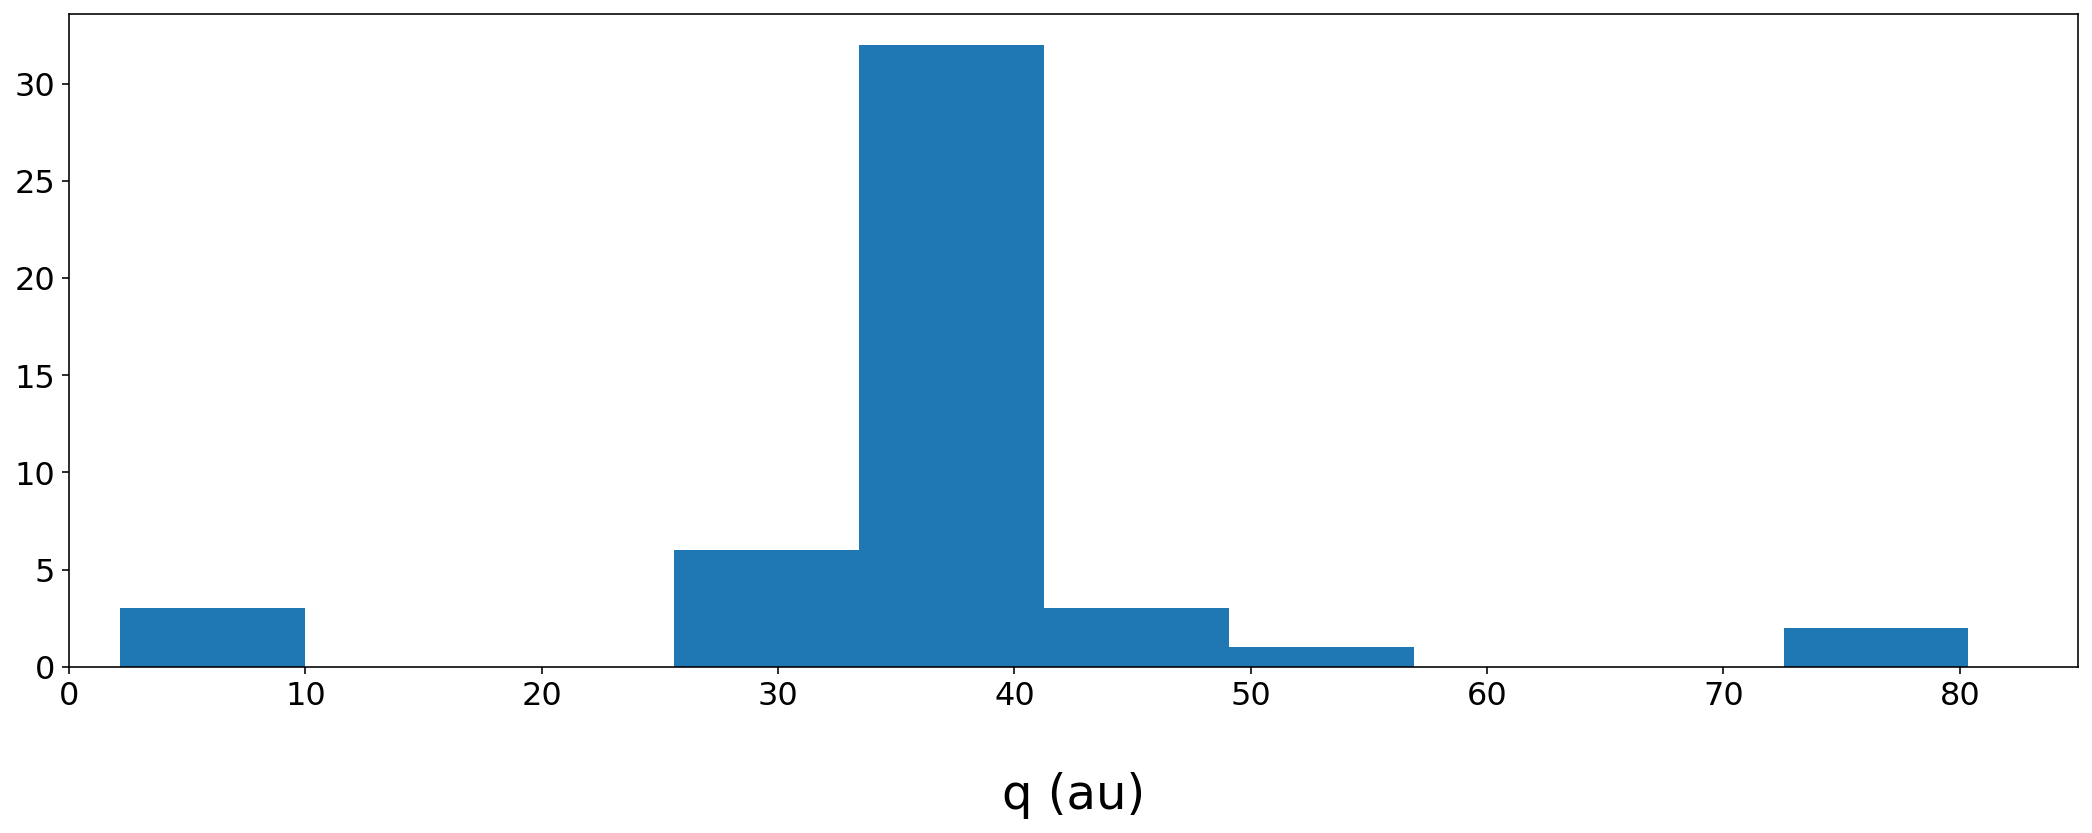

In [70]:
fig, ax = plt.subplots(figsize=(18, 6))
_ = ax.hist(rocks.q.au, bins=10)
ax.set_xlim([0, 85])
ax.tick_params(labelsize=16)
ax.set_xlabel('q (au)', fontsize=24, labelpad=30)

Text(0.5, 0, 'a (au)')

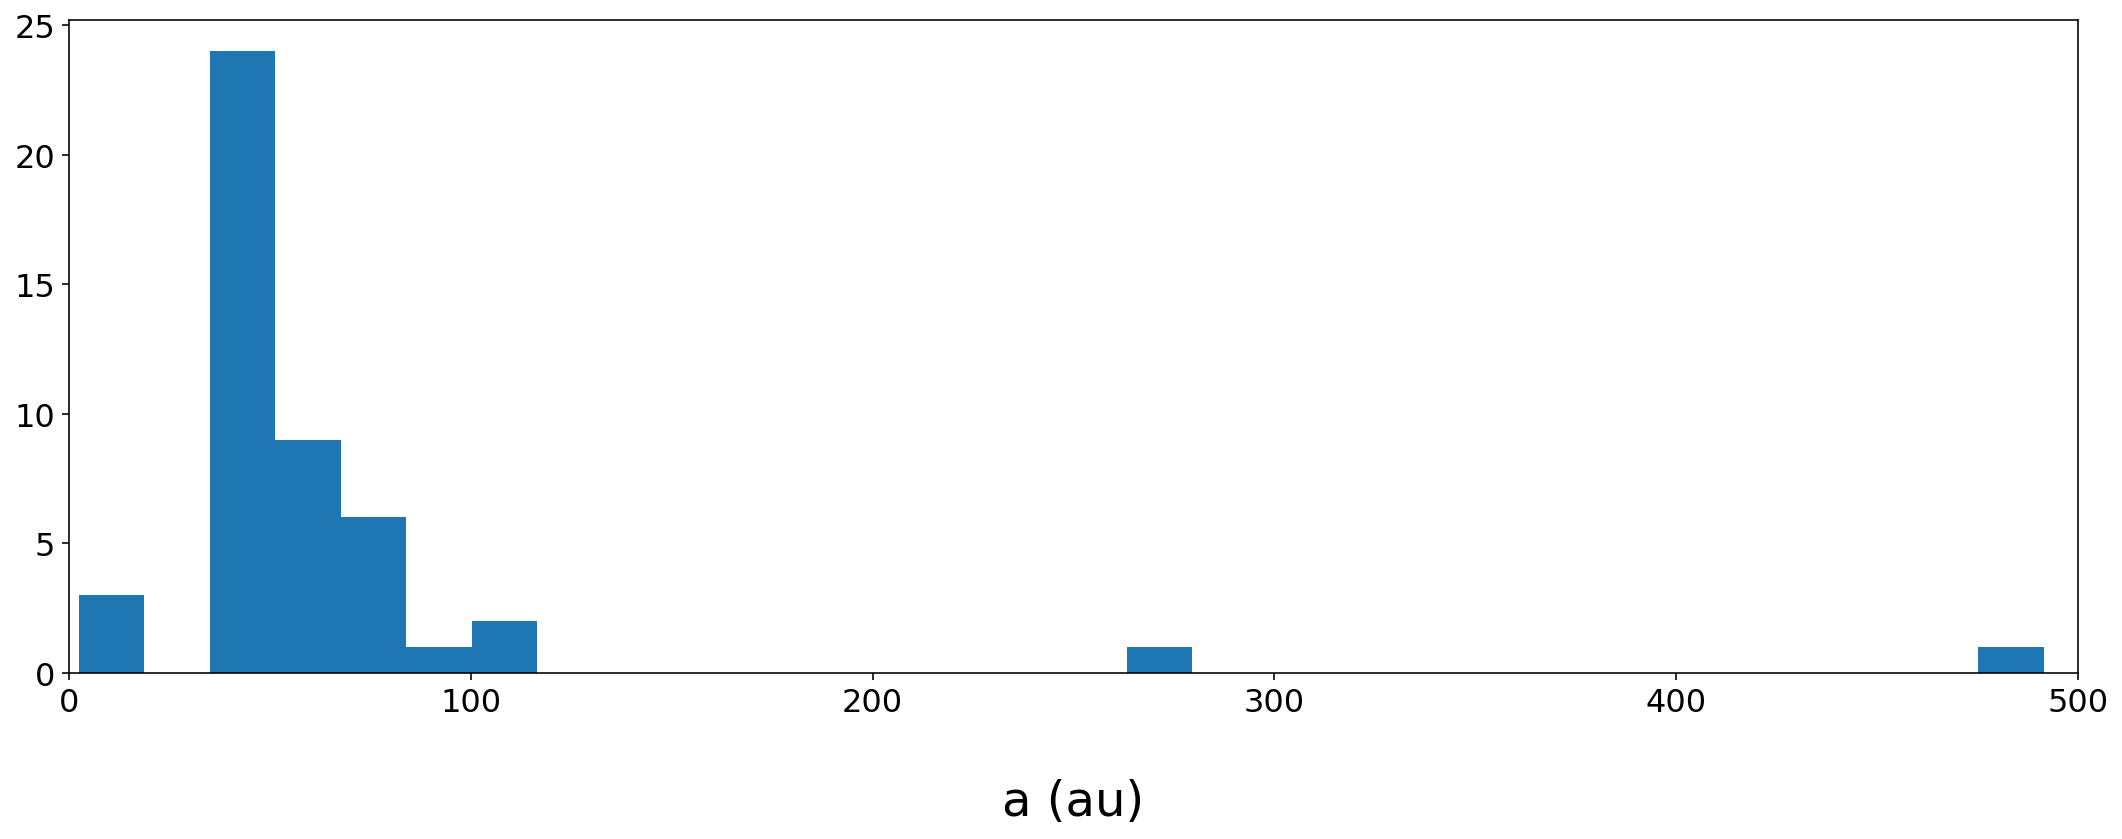

In [74]:
fig, ax = plt.subplots(figsize=(18, 6))
_ = ax.hist(rocks.a.au, bins=30)
ax.set_xlim([0, 500])
ax.tick_params(labelsize=16)
ax.set_xlabel('a (au)', fontsize=24, labelpad=30)

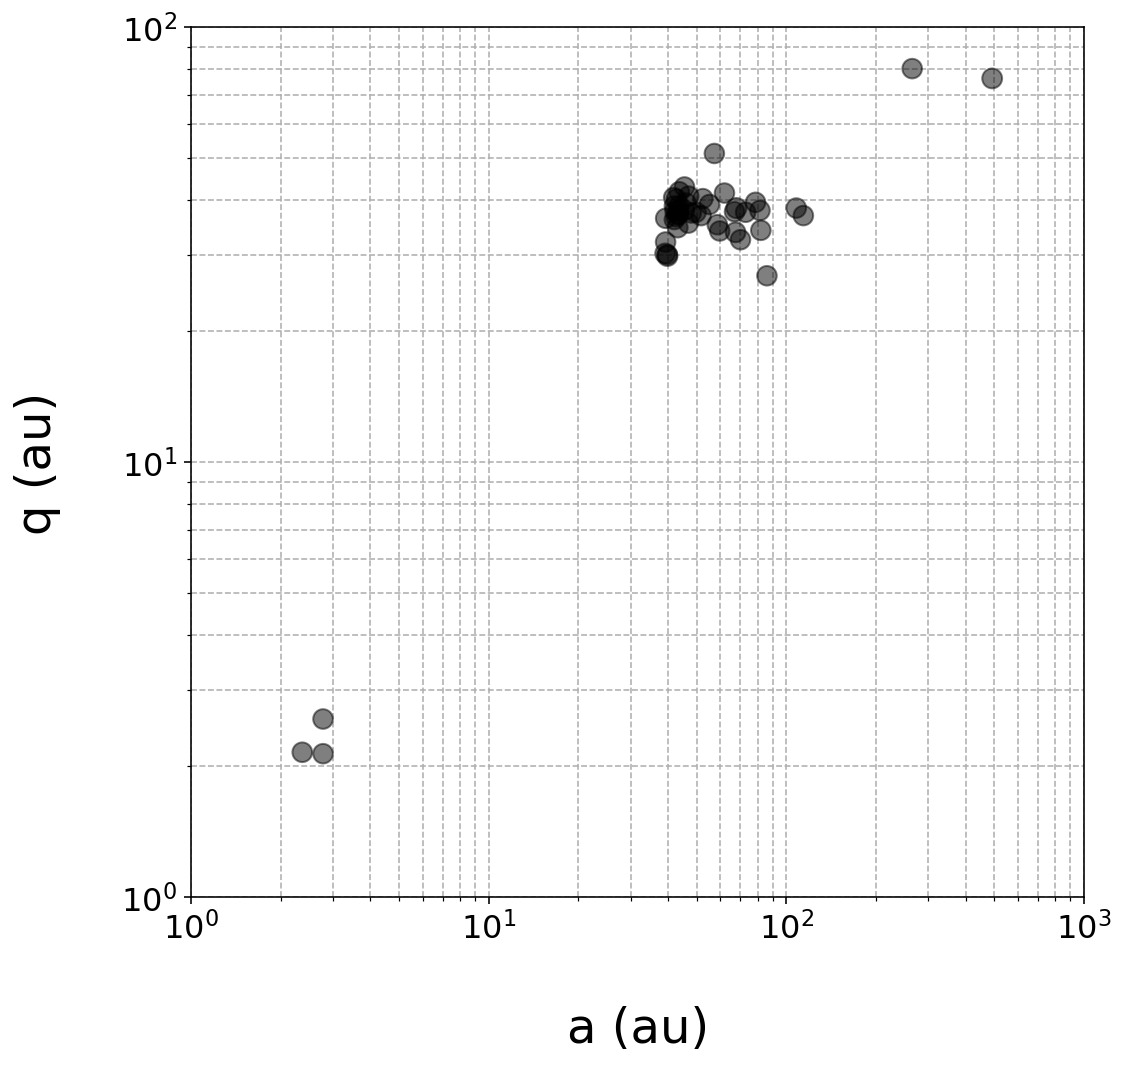

In [100]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(rocks.a.au, rocks.q.au, zorder=10, s=100-df.H.values, color='black', alpha=0.5)
ax.set_xlim([1, 1000])
ax.set_ylim([1, 100])
ax.tick_params(labelsize=16)
ax.set_xlabel('a (au)', fontsize=24, labelpad=30)
ax.set_ylabel('q (au)', fontsize=24, labelpad=30, rotation=90)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(linestyle='--', which='both')

Text(0.5, 0, '$\\sin(inc)$')

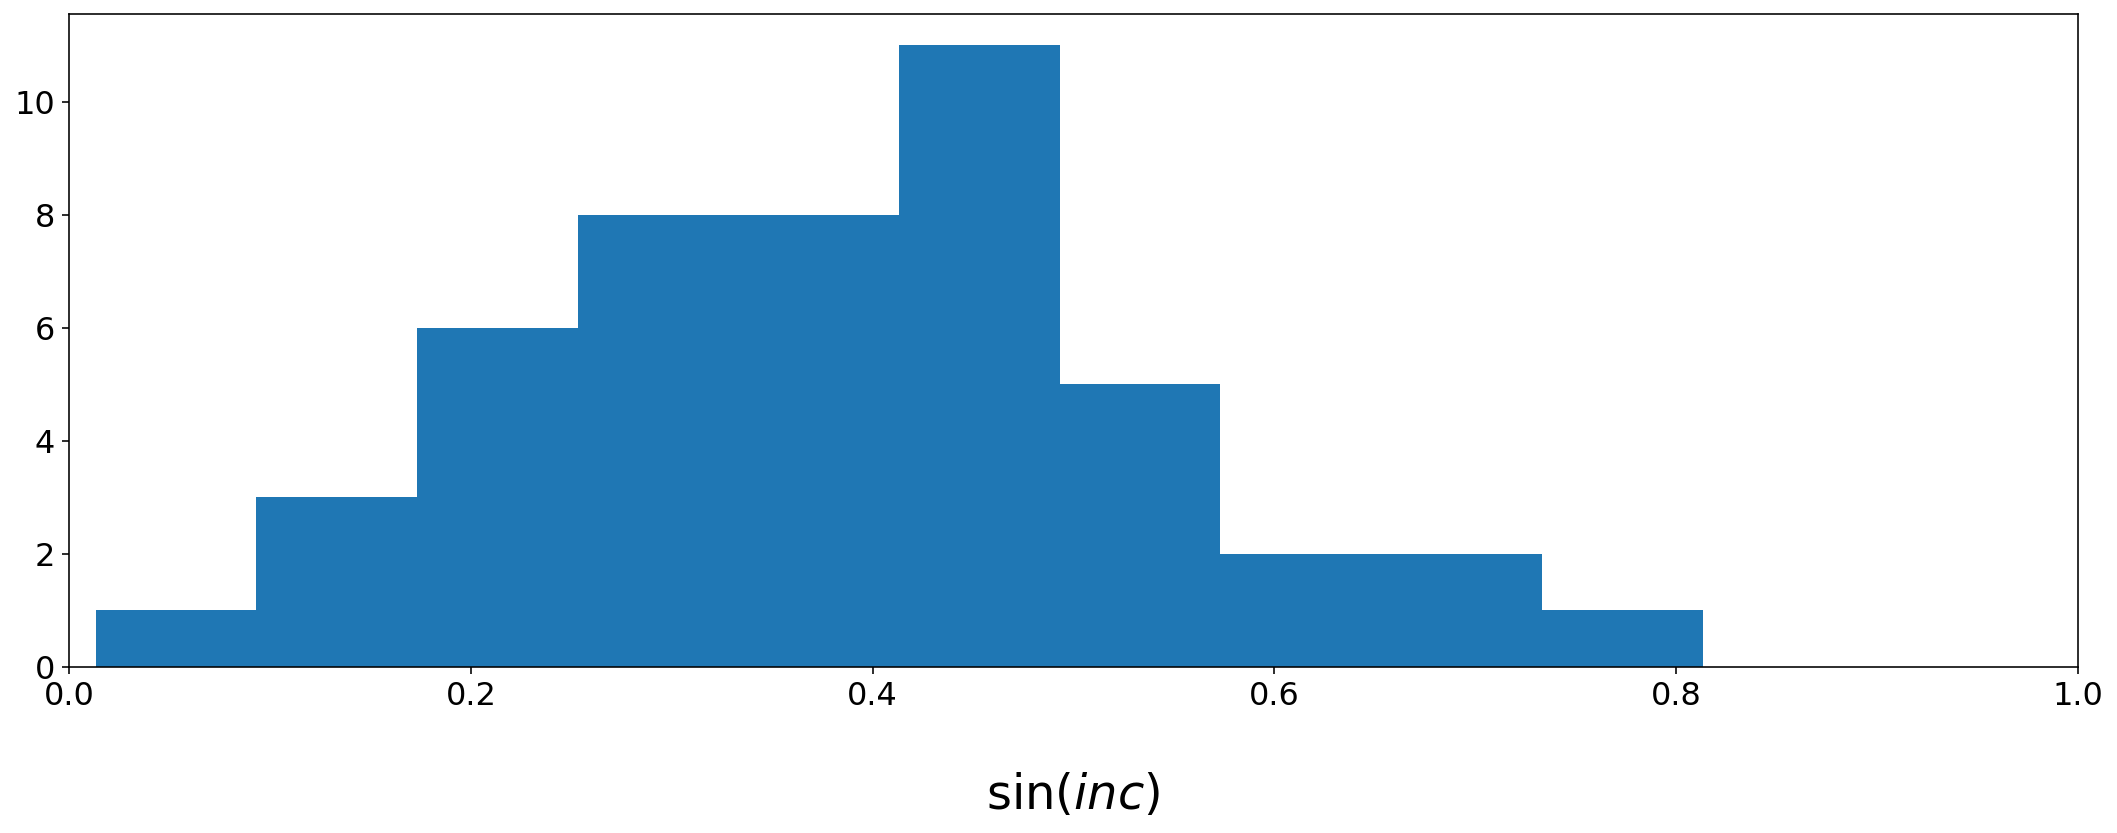

In [114]:
fig, ax = plt.subplots(figsize=(18, 6))
_ = ax.hist(np.sin(rocks.inc.rad), bins=10)
ax.set_xlim([0, 1])
ax.tick_params(labelsize=16)
ax.set_xlabel(r'$\sin(inc)$', fontsize=24, labelpad=30)

Text(0, 0.5, 'e')

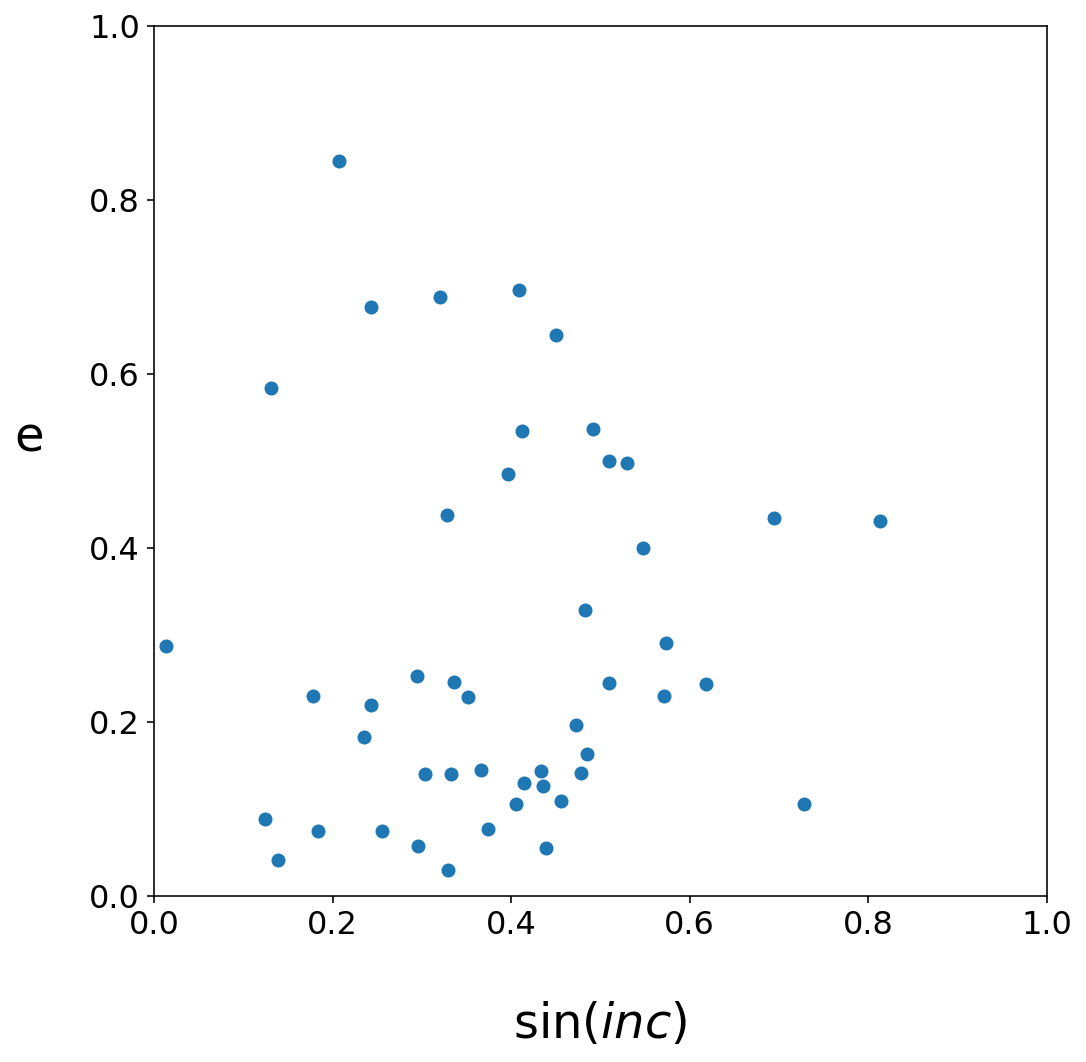

In [120]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(np.sin(rocks.inc.rad), rocks.e)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.tick_params(labelsize=16)
ax.set_xlabel(r'$\sin(inc)$', fontsize=24, labelpad=30)
ax.set_ylabel(r'e', fontsize=24, labelpad=30, rotation=0)

Text(0, 0.5, '$e\\sin(\\varpi)$')

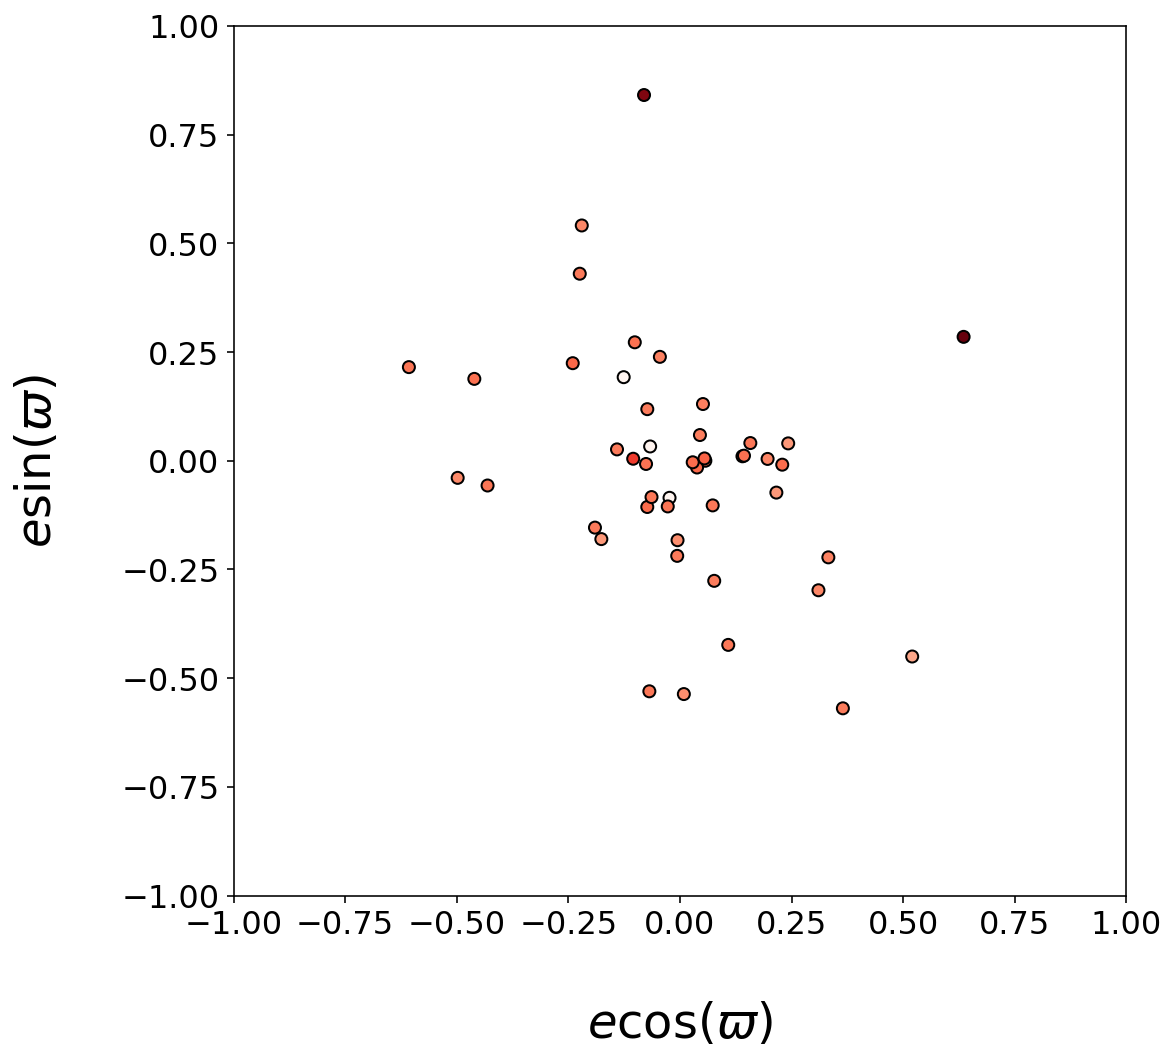

In [127]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(rocks.e * np.cos(rocks.varpi), rocks.e * np.sin(rocks.varpi), c=rocks.q.au, cmap='Reds', edgecolor='black')
ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])
ax.tick_params(labelsize=16)
ax.set_xlabel(r'$e\cos(\varpi)$', fontsize=24, labelpad=30)
ax.set_ylabel(r'$e\sin(\varpi)$', fontsize=24, labelpad=30)

Text(0, 0.5, '$i\\sin(\\Omega)$ (deg)')

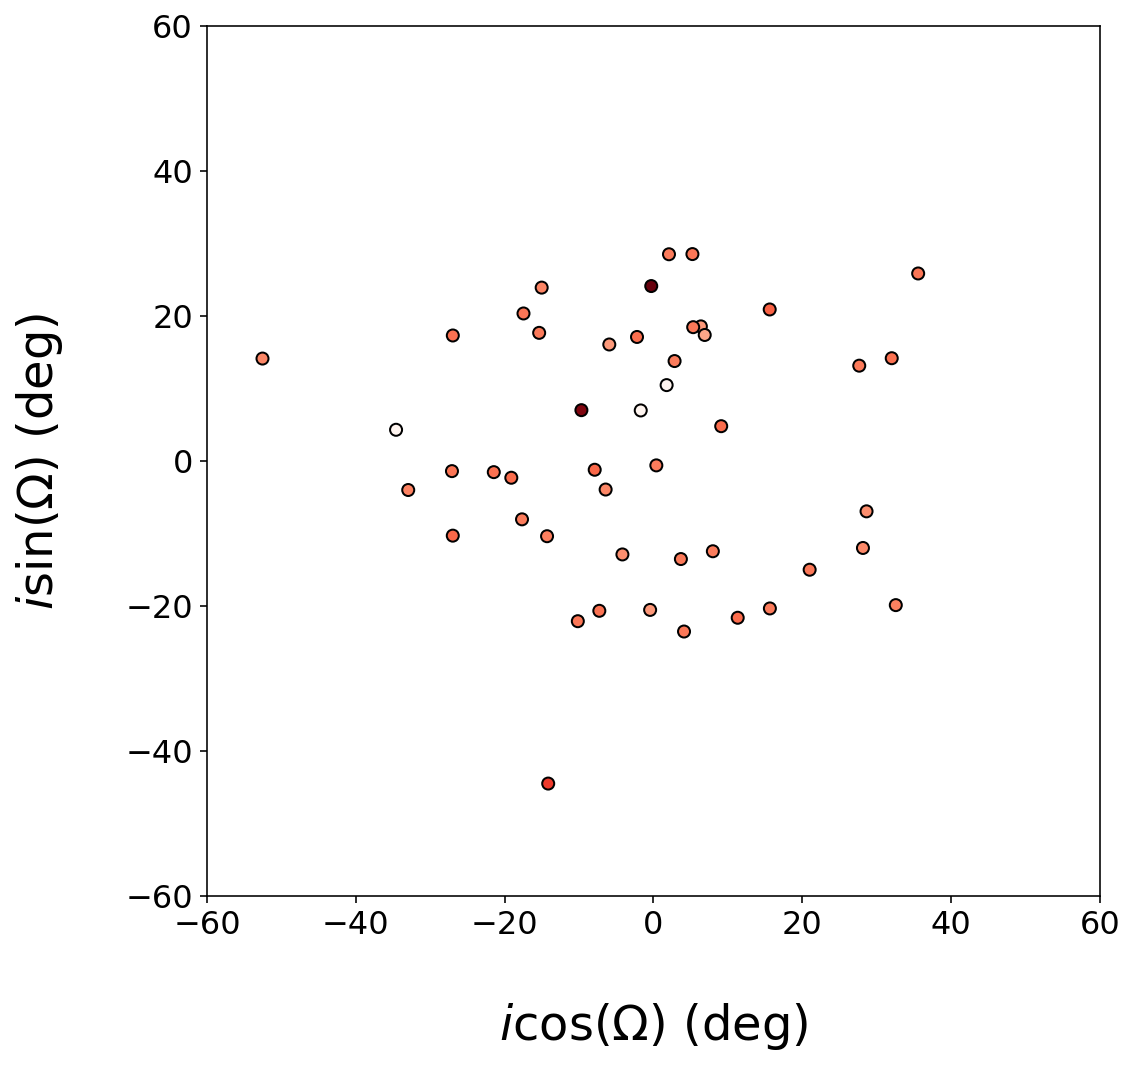

In [130]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(rocks.inc.deg * np.cos(rocks.node), rocks.inc.deg * np.sin(rocks.node), c=rocks.q.au, cmap='Reds', edgecolor='black')
ax.set_xlim([-60, 60])
ax.set_ylim([-60, 60])
ax.tick_params(labelsize=16)
ax.set_xlabel(r'$i\cos(\Omega)$ (deg)', fontsize=24, labelpad=30)
ax.set_ylabel(r'$i\sin(\Omega)$ (deg)', fontsize=24, labelpad=30)

Text(0.5, 0, 'H')

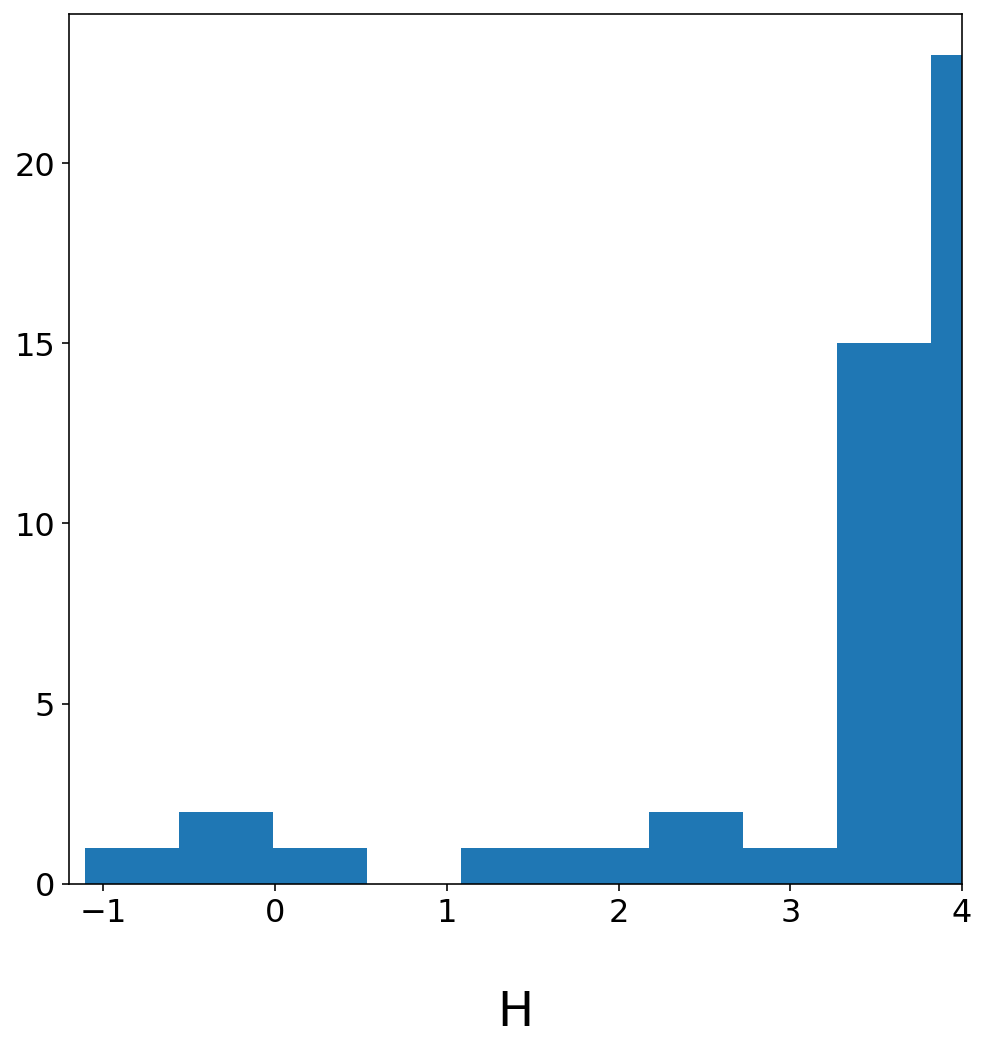

In [116]:
fig, ax = plt.subplots(figsize=(8, 8))
_ = ax.hist(df.H, bins=10)
ax.set_xlim([-1.2, 4])
ax.tick_params(labelsize=16)
ax.set_xlabel('H', fontsize=24, labelpad=30)

(-500.0, 500.0, -500.0, 500.0)

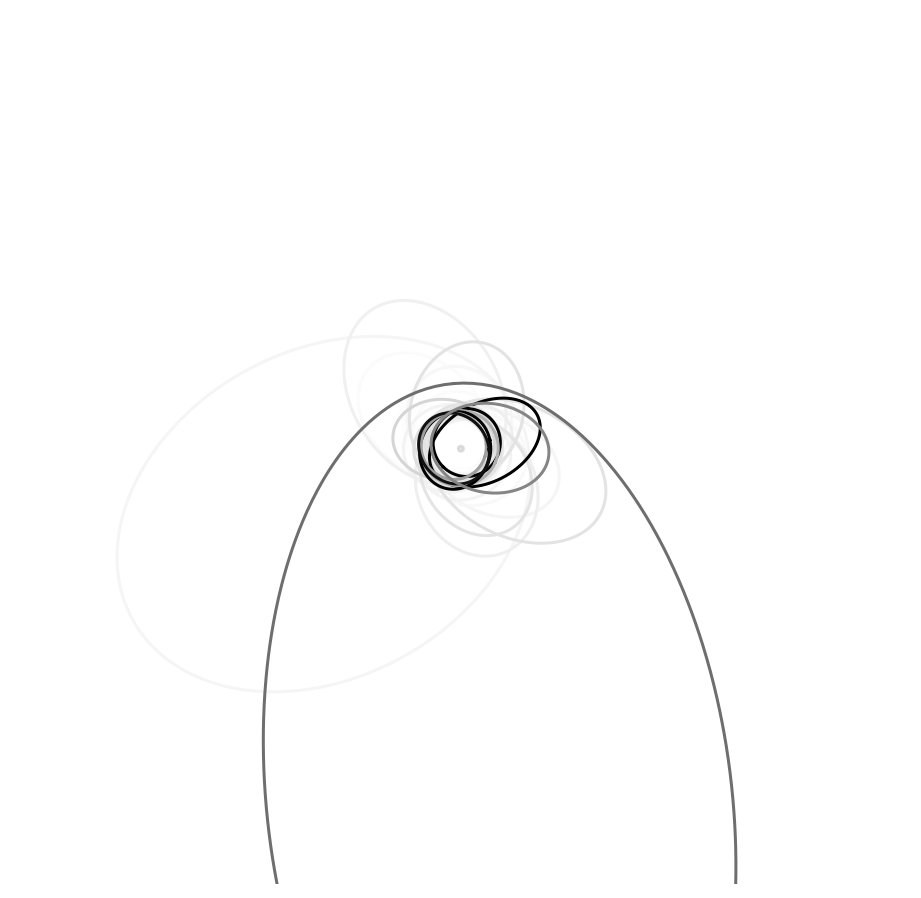

In [69]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes()

for idx in range(len(rocks)):
    ax.plot(x[idx], y[idx], color=cm.Greys_r(df.H.values[idx]/np.max(df.H)), alpha=1, zorder=1/abs(np.min(df.H) + df.H.values[idx]))#, linewidth=1/abs(np.min(df.H) + df.H.values[idx]))
    
#for idx in range(len(rocks)):
#    ax.plot(x[idx], y[idx], color='black', alpha=1/df.H.values[idx])
    
ax.set_xlim([-500, 500])
ax.set_ylim([-500, 500])
ax.axis('off')

(-200.0, 200.0, -200.0, 200.0)

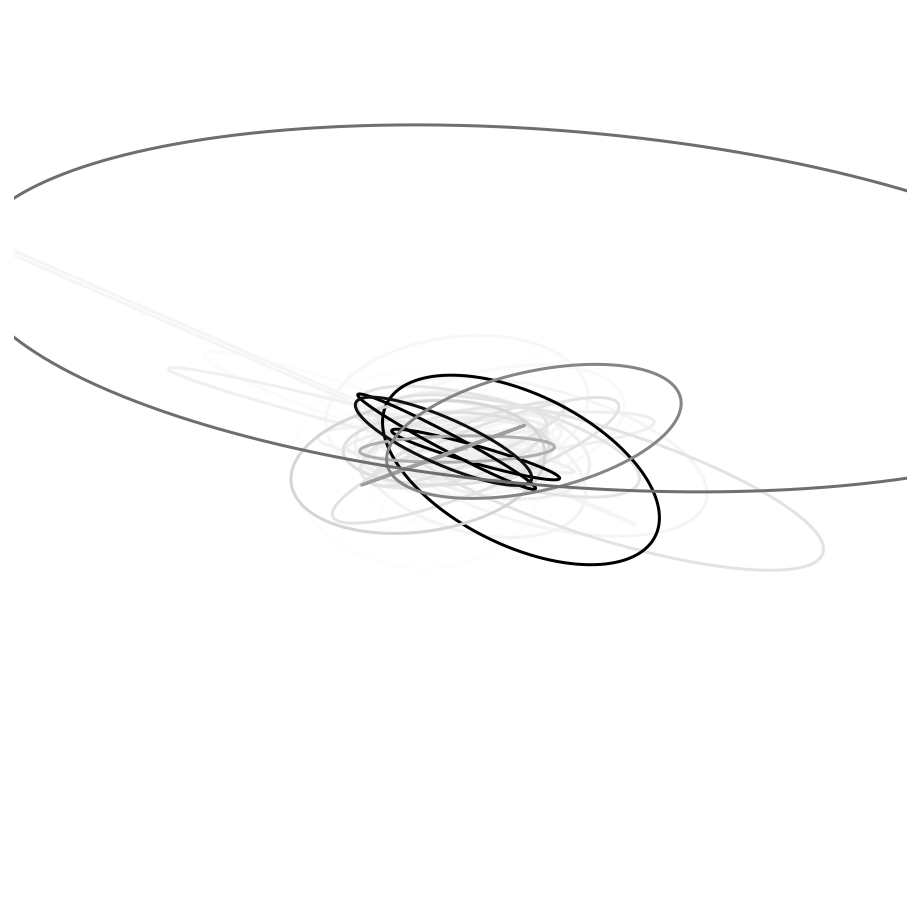

In [104]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes()

for idx in range(len(rocks)):
    ax.plot(x[idx], z[idx], color=cm.Greys_r(df.H.values[idx]/np.max(df.H)), alpha=1, zorder=1/abs(np.min(df.H) + df.H.values[idx]))#, linewidth=1/abs(np.min(df.H) + df.H.values[idx]))
    
#for idx in range(len(rocks)):
#    ax.plot(x[idx], y[idx], color='black', alpha=1/df.H.values[idx])
    
ax.set_xlim([-200, 200])
ax.set_ylim([-200, 200])
ax.axis('off')

(-200.0, 200.0, -200.0, 200.0)

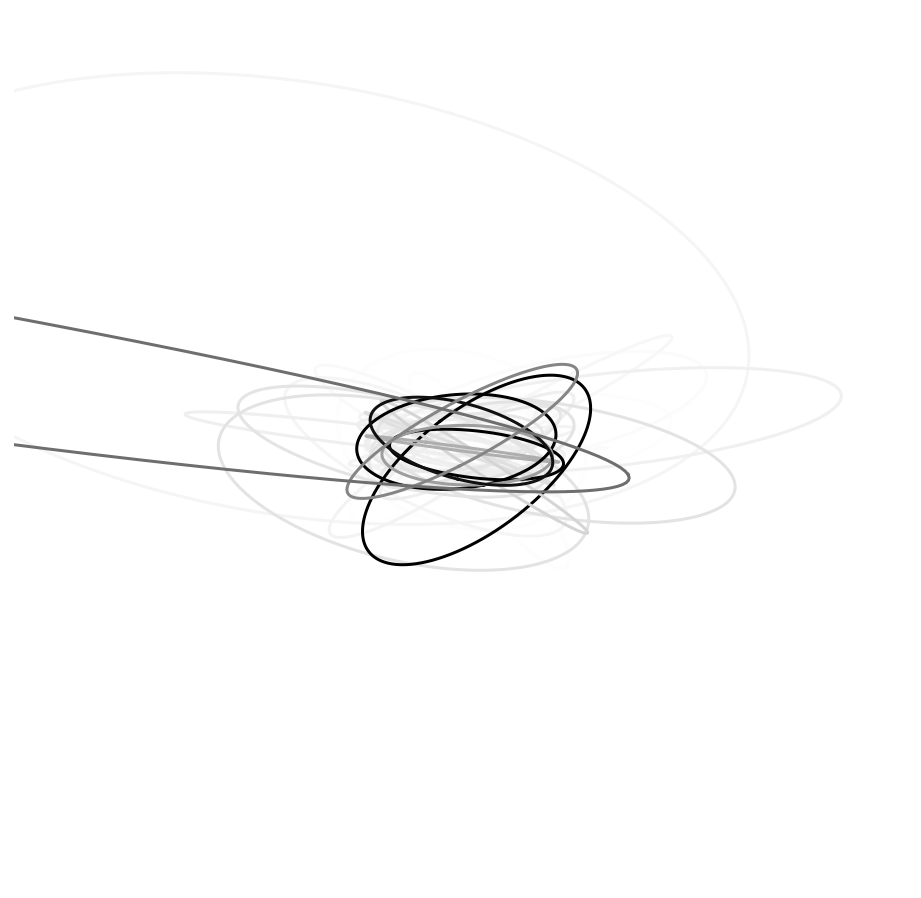

In [105]:
fig = plt.figure(figsize=(8, 8))
ax = plt.axes()

for idx in range(len(rocks)):
    ax.plot(y[idx], z[idx], color=cm.Greys_r(df.H.values[idx]/np.max(df.H)), alpha=1, zorder=1/abs(np.min(df.H) + df.H.values[idx]))#, linewidth=1/abs(np.min(df.H) + df.H.values[idx]))
    
#for idx in range(len(rocks)):
#    ax.plot(x[idx], y[idx], color='black', alpha=1/df.H.values[idx])
    
ax.set_xlim([-200, 200])
ax.set_ylim([-200, 200])
ax.axis('off')

(-100.0, 100.0)

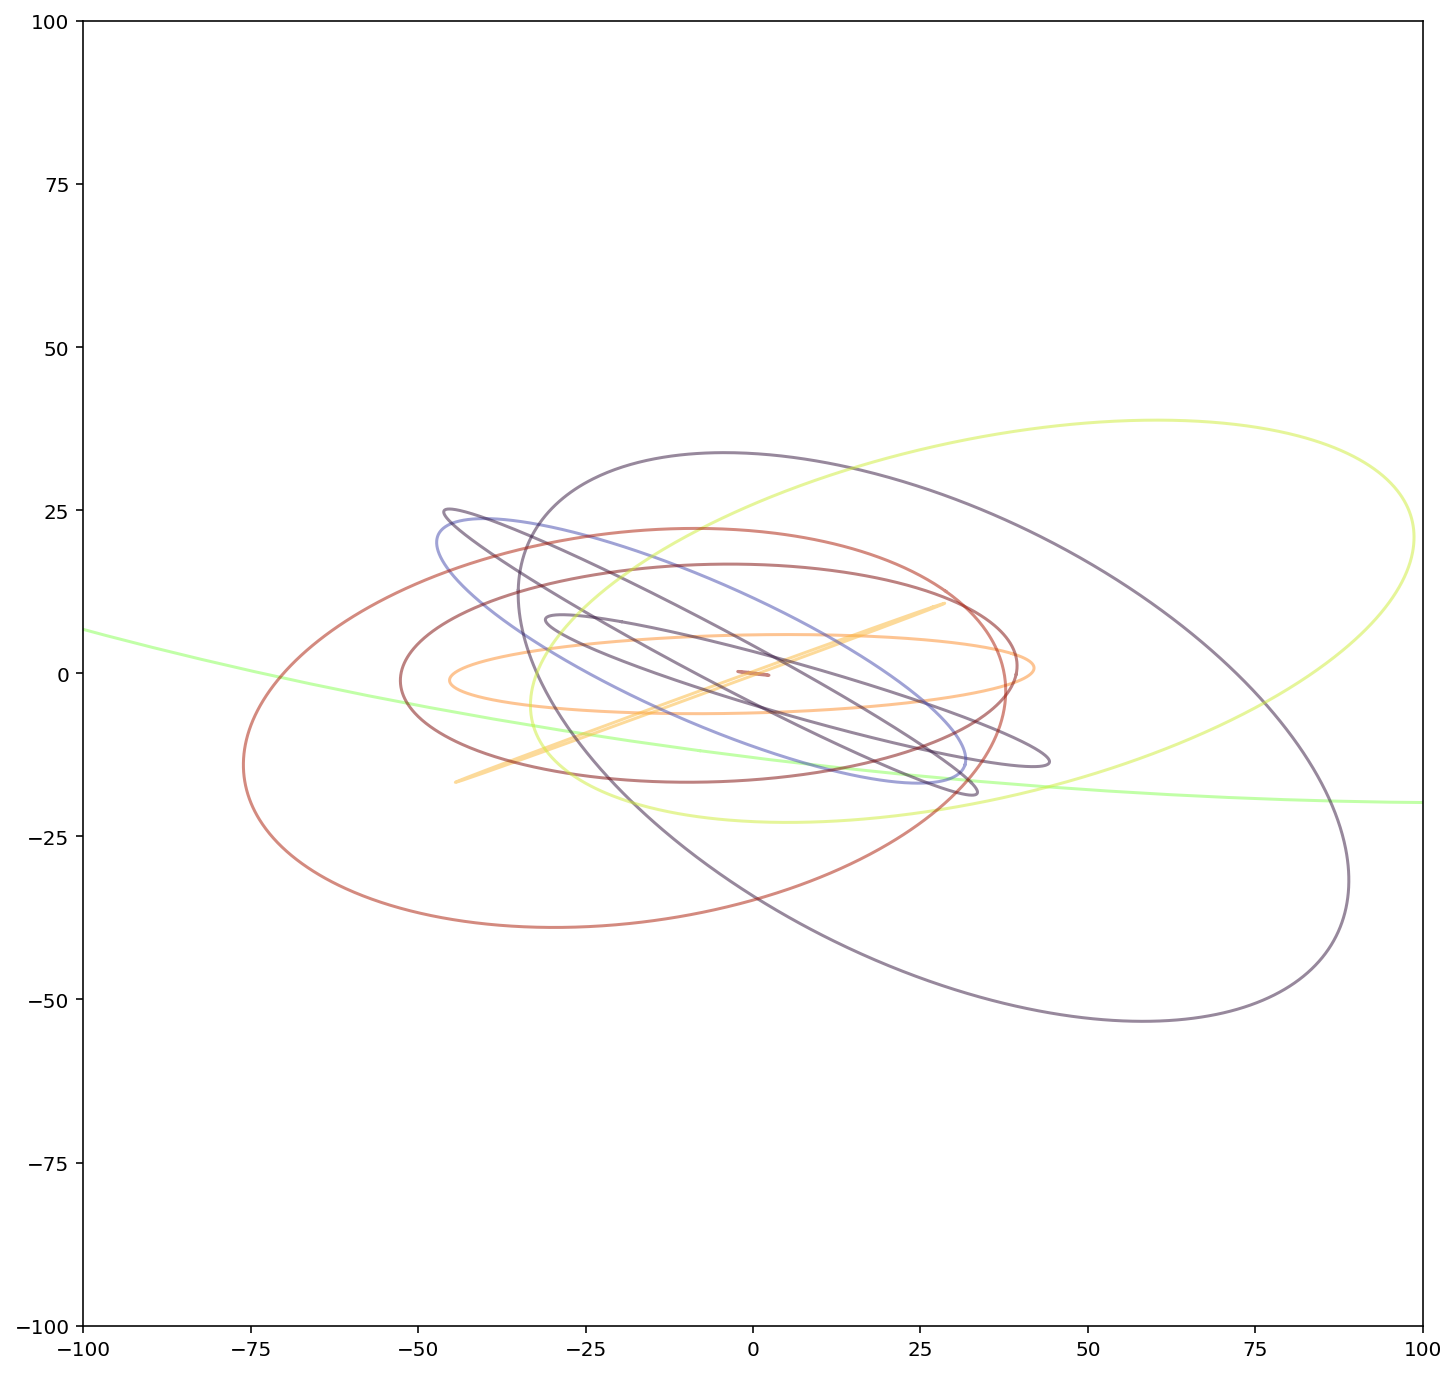

In [123]:
fig = plt.figure(figsize=(12, 12))
ax = plt.axes()

for idx in range(len(rocks)):
    ax.plot(x[idx], z[idx], alpha=0.5, color=cm.turbo(df.H.values[idx]/np.max(df.H)))
    
ax.set_xlim([-100, 100])
ax.set_ylim([-100, 100])

(-100.0, 100.0)

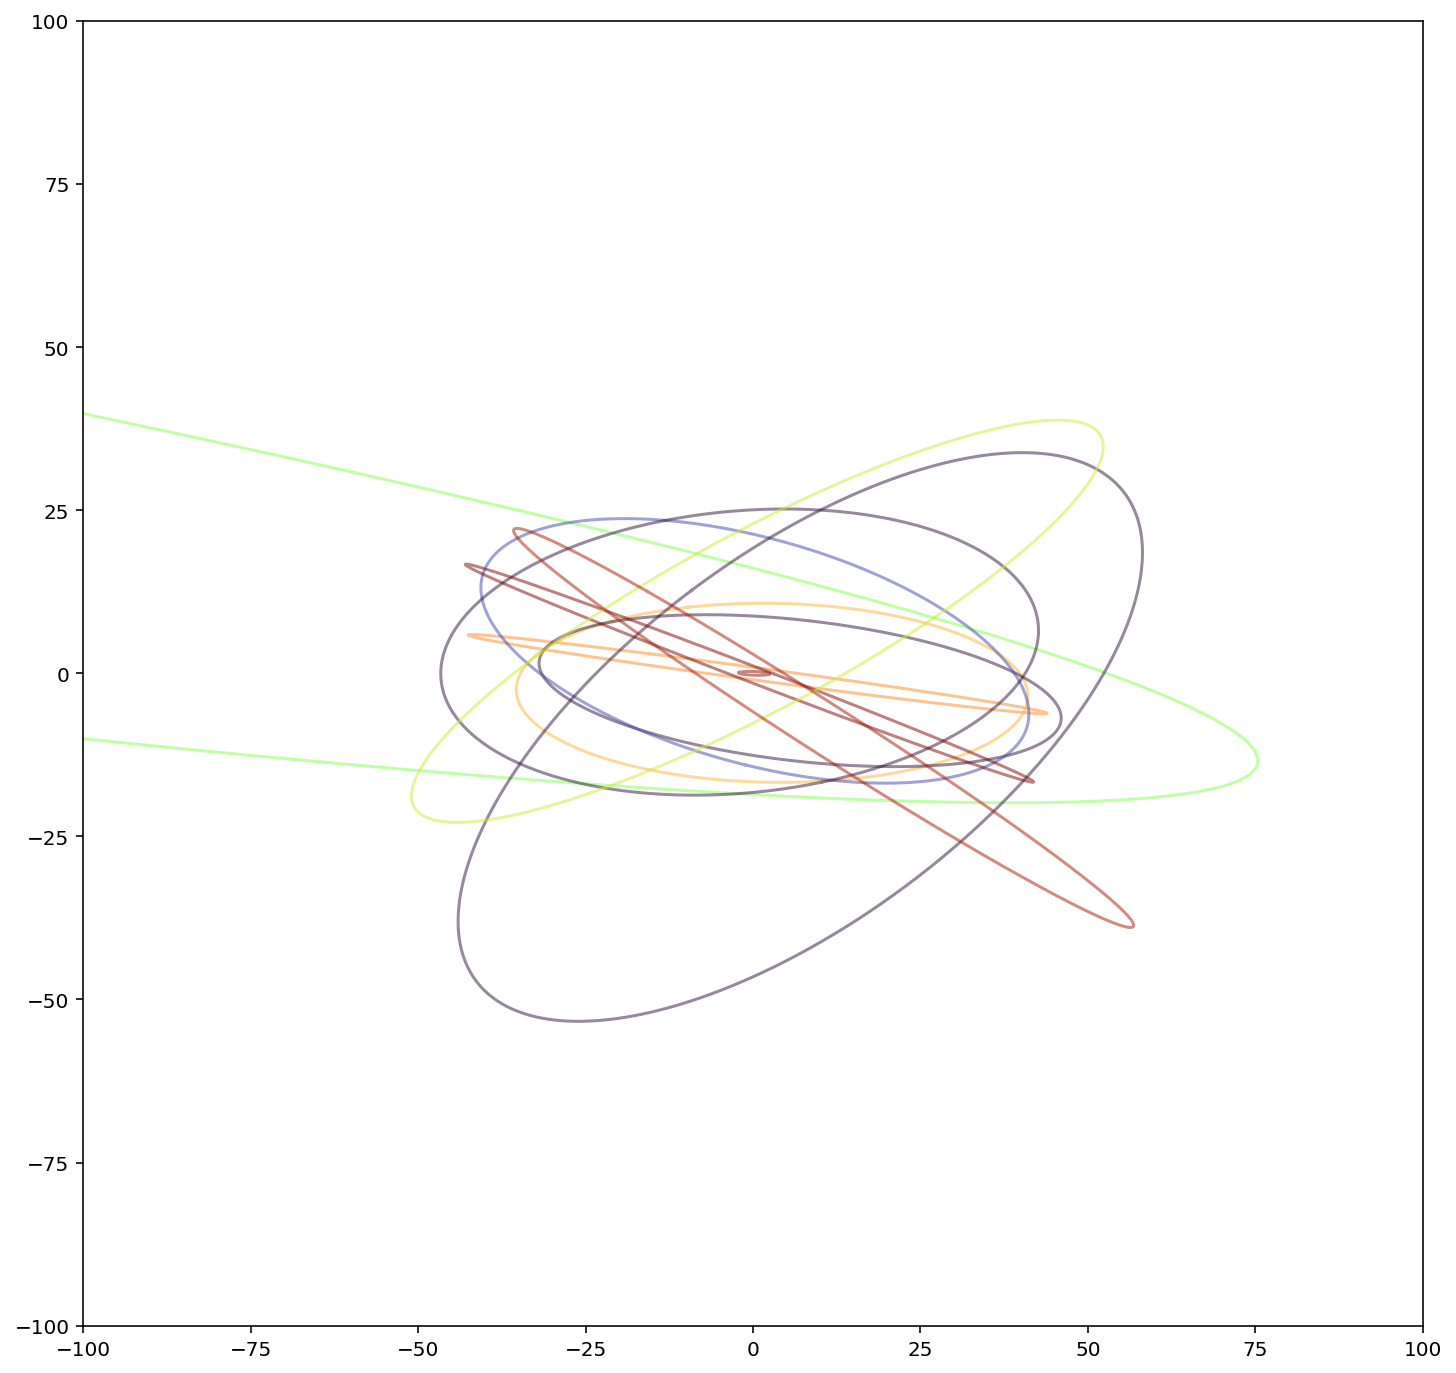

In [124]:
fig = plt.figure(figsize=(12, 12))
ax = plt.axes()

for idx in range(len(rocks)):
    ax.plot(y[idx], z[idx], color=cm.turbo(df.H.values[idx]/np.max(df.H)), alpha=0.5)
    
ax.set_xlim([-100, 100])
ax.set_ylim([-100, 100])